/home/ashiquetnizar/miniconda3/envs/nrgw/lib/python3.6/site-packages/ipykernel_launcher.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


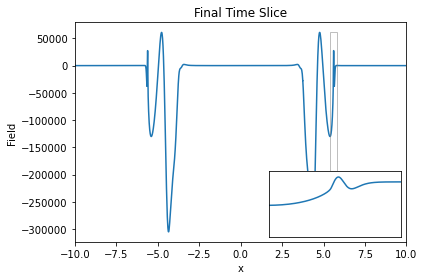

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# =========================
# 1. READ FILE + GET LAST TIME SLICE
# =========================

filename = "/media/ashiquetnizar/BA78F8F778F8B36D/Common/Data_Cluster_transfer/A4.11_4.11/etadm_4.5_1000gamma2alone/test_4.11_4.11_etadm4.5_1000gamma2alone/output_1d/z/ana.CSI.tgrf"   # <-- change this

blocks = []
current_block = []

with open(filename, "r") as f:
    for line in f:
        line = line.strip()

        if not line:
            continue

        if line.startswith("#"):  # new time block
            if current_block:
                blocks.append(np.array(current_block))
                current_block = []
        else:
            parts = line.split()
            current_block.append([float(parts[0]), float(parts[1])])

# append last block
if current_block:
    blocks.append(np.array(current_block))

# take last time slice
last = blocks[-1]
x = last[:, 0]
y = last[:, 1]

# =========================
# 2. MAIN PLOT
# =========================

fig, ax = plt.subplots()
ax.set_xlim(left=-10,right=10)
ax.plot(x, y)
ax.set_xlabel("x")
ax.set_ylabel("Field")
ax.set_title("Final Time Slice")

# =========================
# 3. INSET ZOOM
# =========================

axins = inset_axes(ax, width="40%", height="30%", loc="lower right")
axins.plot(x, y)
# ---- CHANGE THIS REGION ----
# Pick where your spike / interesting feature is
x1, x2 = 5.4, 5.8
y1, y2 = np.min(y), np.max(y)
# ---------------------------

axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
axins.grid(True, which='both', linestyle='--', linewidth=0.4)
axins.minorticks_on()
axins.set_xticks([])
axins.set_yticks([])

# draw box on main plot
ax.indicate_inset_zoom(axins)

# =========================
# 4. SAVE FOR LATEX
# =========================

plt.tight_layout()
plt.savefig("final_slice.pdf")  # <-- use this in LaTeX
plt.show()

/home/ashiquetnizar/miniconda3/envs/nrgw/lib/python3.6/site-packages/ipykernel_launcher.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


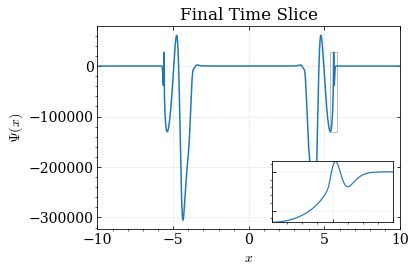

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# =========================
# LaTeX-style plotting
# =========================
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.labelsize": 14,
    "font.size": 14,
})

# =========================
# 1. READ FILE + GET LAST TIME SLICE
# =========================

filename = "/media/ashiquetnizar/BA78F8F778F8B36D/Common/Data_Cluster_transfer/A4.11_4.11/etadm_4.5_1000gamma2alone/test_4.11_4.11_etadm4.5_1000gamma2alone/output_1d/z/ana.CSI.tgrf"

blocks = []
current_block = []

with open(filename, "r") as f:
    for line in f:
        line = line.strip()

        if not line:
            continue

        if line.startswith("#"):  # new time block
            if current_block:
                blocks.append(np.array(current_block))
                current_block = []
        else:
            parts = line.split()
            current_block.append([float(parts[0]), float(parts[1])])

# append last block
if current_block:
    blocks.append(np.array(current_block))

# take last time slice
last = blocks[-1]
x = last[:, 0]
y = last[:, 1]

# =========================
# 2. MAIN PLOT
# =========================

fig, ax = plt.subplots(figsize=(6,4))

ax.set_xlim(-10, 10)
ax.plot(x, y, linewidth=1.5)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$\Psi(x)$")   # change variable if needed
ax.set_title(r"Final Time Slice")

# Main grid
ax.grid(True, linestyle=':', linewidth=0.5)
ax.minorticks_on()
ax.tick_params(direction='in', top=True, right=True)

# =========================
# 3. INSET ZOOM
# =========================

axins = inset_axes(ax, width="40%", height="30%", loc="lower right")

axins.plot(x, y, linewidth=1.2)

# ---- ZOOM REGION ----
x1, x2 = 5.4, 5.8

mask = (x > x1) & (x < x2)
y1, y2 = y[mask].min(), y[mask].max()

axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)

# Grid inside inset
axins.grid(True, linestyle=':', linewidth=0.4)
axins.minorticks_on()

# Keep ticks but hide labels (so grid works)
axins.tick_params(direction='in', labelbottom=False, labelleft=False)

# Optional: log scale if spike is sharp
# axins.set_yscale('log')

# Draw zoom box
ax.indicate_inset_zoom(axins)

# =========================
# 4. SAVE FOR LATEX
# =========================

plt.tight_layout()
plt.savefig("final_slice.pdf")
plt.show()